# Generating City

Melhorar instancia:
	colocar prêmios e custos como rand*dist
	fator aleatório x entre (1, 4), não entre (1, 100) (ver ali em baixo *)
	fazer um grafo não completo (cada vértice se liga a de 1 a 8 outros, maior prob aos pertos **)
	anotar quantas arestas de cada instancia

*: sorteie um número real x em [0,1) e faça fator = 4^(0,5-x) -> [0.5, 2]


**: 
seja i o i-ésimo vértice mais próximo do atual
i=0 é o vizinho mais próximo, i=1 é o segundo, e assim por diante
pra cada vértice i associe peso 1/2^i
seja T a soma dos pesos de todos os vértices
sorteie um número entre 0 e T e veja na faixa de quem ele cai



QUESTÔES:
- Componentes desconexas (Adaptei MST para)

In [100]:
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import time


In [101]:
m = 5
n = 10
pos = []
seed = int(time.time())
random.seed(seed)
print("Seed usada:", seed)
for i in range(m+n+1):
    x = random.randint(0, 100)
    y = random.randint(0, 100)
    pos.append((i, x, y))

for i, x, y in pos:
    print(f'{i}: ({x}, {y})')


Seed usada: 1788881419
0: (95, 81)
1: (65, 92)
2: (93, 85)
3: (43, 47)
4: (61, 96)
5: (30, 95)
6: (53, 90)
7: (0, 22)
8: (78, 75)
9: (85, 29)
10: (1, 1)
11: (7, 33)
12: (85, 66)
13: (75, 14)
14: (33, 60)
15: (7, 36)


In [102]:
def dist(u, v):
    return ((u[2]-v[2])**2 + (u[1]-v[1])**2)**0.5


def mst(pos, dist_func):
    n = len(pos)
    
    in_mst = [False] * n
    key = [float("inf")] * n   # menor custo para conectar cada vértice
    parent = [-1] * n          # pai na MST
    
    key[0] = 0  # começa pelo vértice 0
    
    for _ in range(n):
        # escolhe o vértice fora da MST com menor key
        u = -1
        best = float("inf")
        for i in range(n):
            if not in_mst[i] and key[i] < best:
                best = key[i]
                u = i
        
        in_mst[u] = True
        
        # relaxa as arestas (u, v) para todos os v fora da MST
        for v in range(n):
            if not in_mst[v]:
                w = dist_func(pos[u], pos[v])
                if w < key[v]:
                    key[v] = w
                    parent[v] = u
    
    # monta a matriz de adjacência da MST
    adj = [[0.0] * n for _ in range(n)]
    
    for v in range(1, n):
        u = parent[v]
        w = dist_func(pos[u], pos[v])
        adj[u][v] = w
        adj[v][u] = w
    
    return adj

In [103]:
g = mst(pos, dist)

g = np.array(g).astype(float)


In [104]:
def show_graph(g, pos):
    G = nx.from_numpy_array(g)
    node_colors = ['lightgreen' if i < m+1 else 'red' for i in range(len(G))]

    nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color='gray')

    plt.show()


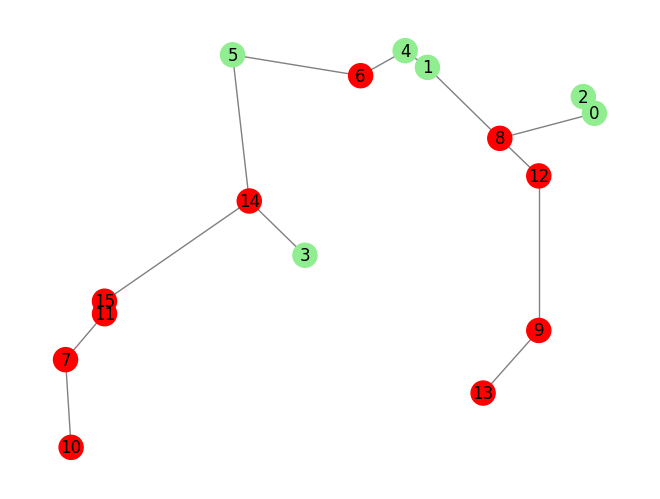

In [105]:
g = np.matrix(g)
poss = np.array([p[1:3] for p in pos])
show_graph(g, poss)

In [106]:
edge_list = []

for u in range(len(pos)):
    for v in range(u+1, len(pos)):
        edge_list.append((dist(pos[u], pos[v]), u, v))

edge_list = sorted(edge_list)

edge_count = y+x
max_edge_count = 2 #random.uniform(1.5, 2.5)
max_degree = [0] * (m+n+1)
for i in range(len(max_degree)):
    max_degree[i] = random.randint(2, 6)

for d, u, v in edge_list:
    if g[u, v] == 0 and edge_count < max_edge_count*(y+x+1) and ((g[u, :] != 0).sum() < max_degree[u]) and ((g[:, v] != 0).sum() < max_degree[v]):
        g[u, v] = d
        g[v, u] = d
        edge_count+=1
print(f'|edge_list| == {len(edge_list)}')
print(f'max number of edges == {max_edge_count*(y+x+1)}')
print(f'edge_count == {edge_count}')
print(f'max_degree == {max_degree}')

|edge_list| == 120
max number of edges == 88
edge_count == 56
max_degree == [4, 2, 5, 6, 4, 3, 4, 3, 2, 2, 5, 4, 4, 5, 3, 3]


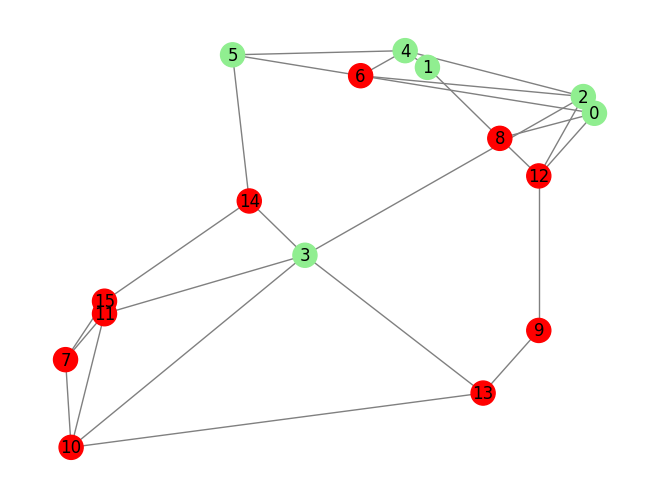

In [107]:
g = np.matrix(g)
poss = np.array([p[1:3] for p in pos])
show_graph(g, poss)

g_bin = (g != 0).astype(int)


# Esse desenho representa a cidade (e suas ruas)

In [108]:
from collections import defaultdict

def has_path(edges, start, target):
    """
    Verifica se existe caminho de start até target usando DFS
    edges: lista de arestas (u, v, w)
    """
    # Construir lista de adjacência
    adj = defaultdict(list)
    for u, v, w in edges:
        adj[u].append(v)
        adj[v].append(u)  # grafo não-direcionado

    # DFS
    stack = [start]
    visited = set()

    while stack:
        node = stack.pop()
        if node == target:
            return True
        if node not in visited:
            visited.add(node)
            stack.extend(adj[node])

    return False

[(0, 0), (0, 12), (12, 2), (12, 8), (2, 6), (2, 3)]


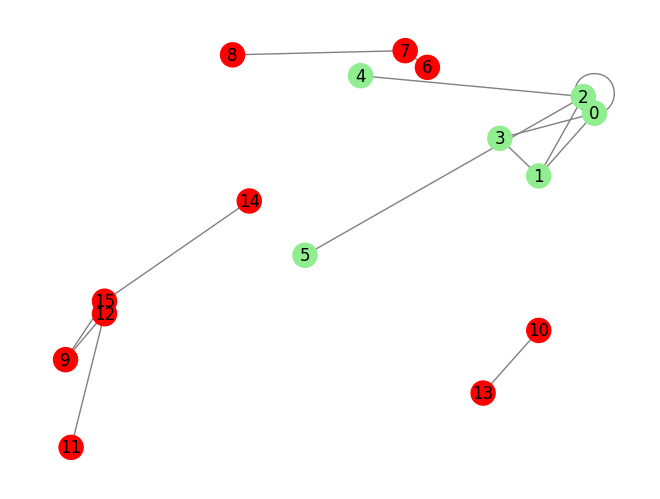

In [109]:
# Aqui eu preciso de um código para descrever as arestas impactadas pela bomba dos EUA no Irã
def BombProposal1(vertices, edges, m, n, prob):
    truck_tree = [] 

    stack = [(0, 0)]
    visited = set()

    while stack and len(truck_tree) <= m:
        node_orig, node_dest = stack.pop(random.randint(0, len(stack) - 1))

        if node_dest not in visited:
            truck_tree.append((node_orig, node_dest))
            visited.add(node_dest)
            for i in range(m+n+1):
                if edges[(node_dest, i)] > 0:
                    stack.append((node_dest, i))


    vert = []
    for i in range(len(truck_tree)):
        u, v = truck_tree[i]
        vert.append(vertices[v])
    for v in vertices:
        if v not in vert:
            vert.append(v)
    
    vertices[:] = vert
    truck_tree_remapped = []
    for tt in truck_tree:
        u, v = tt
        u_l = -1
        v_l = -1
        for i, vertice in enumerate(vertices):
            if vertice[0] == u:
                u_l = i
            if vertice[0] == v:
                v_l = i
        truck_tree_remapped.append((u_l, v_l))

    print(truck_tree)
    old_new_map = dict()
    for i, vertice in enumerate(vert):
        old_new_map[vertice[0]] = i

    new_edges = edges.copy()
    for i in range(len(edges)):
        for j in range(len(edges)):
            new_edges[old_new_map[i], old_new_map[j]] = edges[i, j]
    edges[:] = new_edges

    for i in range(len(vertices)):
        vertices[i] = (i, vertices[i][1], vertices[i][2])

    graph = np.zeros((m+n+1, m+n+1))
    for u, v in truck_tree_remapped:
        graph[u, v] = 1
        graph[v, u] = 1

    for i in range(m + 1):
        for j in range(m+1):
            graph[i, j] = graph[i, j] or ((edges[i, j] != 0) * (random.uniform(0, 1) < prob))

    for i in range(m + 1, len(edges)):
        for j in range(m+1, len(edges)):
            graph[i, j] = (edges[i, j] != 0) * (random.uniform(0, 1) < prob)
    return graph

prop1 = BombProposal1(pos, g_bin, m, n, 0.5)
poss = np.array([p[1:3] for p in pos])
show_graph(prop1, poss)

# Generating Instance

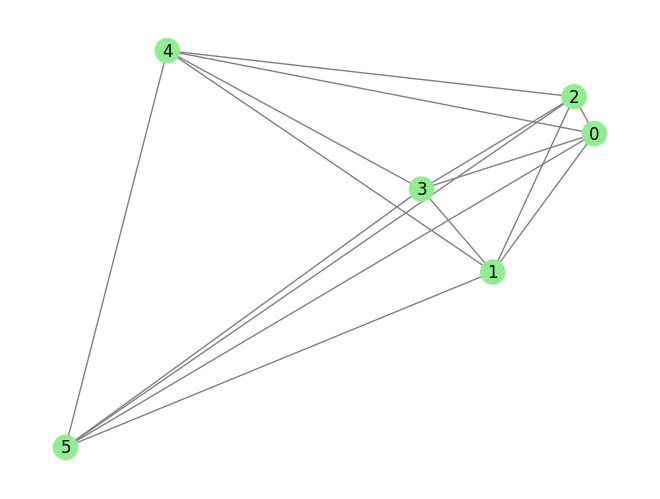

In [110]:
# alpha quao reta é a rua
def truck_network(vertices, edges, m, n, alpha):
    size = m+n+1
    tn = edges.copy()

    for i in range(size):
        for j in range(size):
            if tn[i, j]:
                tn[i, j] = alpha * dist(vertices[i], vertices[j])

    for i in range(size):
        for j in range(size):
            if tn[i, j] == 0:
                tn[i, j] = float('inf')
        tn[i,i] = 0

    # Ffloyd-Warshall
    for k in range(size):
        for i in range(size):
            for j in range(size):
                tn[i][j] = min(tn[i, j], tn[i, k] + tn[k, j])

    return tn[:m+1, :m+1]

tn = truck_network(pos, prop1, m, n, 1.5)
show_graph(tn, poss)



Drone Distance Graph:


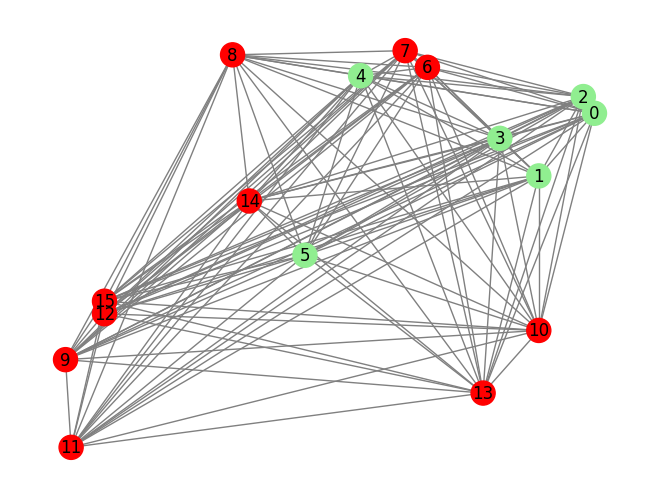

Drone Profit Graph:


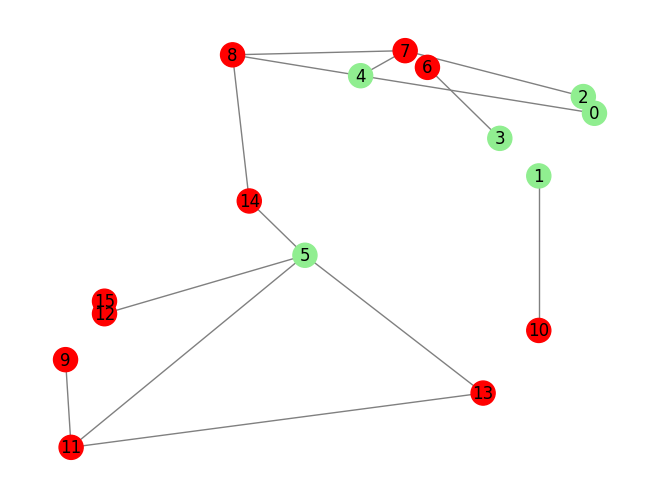

In [111]:
# gamma é o quanto de volta aquela rua dá
def drone_network(vertices, edges_city, edges_survived, m, n, gamma):
    size = m + n + 1
    dn = np.zeros((size, size), dtype=float)
    dp = np.zeros((size, size), dtype=int)

    # drone network
    for i in range(size):
        for j in range(size):
            # existe road
            if edges_city[i, j]:
                dn[i][j] = gamma * dist(vertices[i], vertices[j])
            # nao existe road
            else:
                dn[i][j] = dist(vertices[i], vertices[j])

    # drone profit
    for i in range(size):
        for j in range(i + 1, size):
            dp[i, j] = 0
            dp[j, i] = 0
            # existe road
            if edges_city[i, j] and not edges_survived[i, j]:
                    road_profit = int(random.uniform(0, 1) * dn[i,j])
                    dp[i, j] = road_profit
                    dp[j, i] = road_profit


    return dn, dp

dn, dp = drone_network(pos, g_bin, prop1, m, n, 1.5)
print("Drone Distance Graph:")
show_graph(dn, poss)

print("Drone Profit Graph:")
show_graph(dp, poss)



In [112]:
def print_network(network, t):
    for i in range(network.shape[0]):
        for j in range(network.shape[1]):
            if t is float:
                print(f'{network[i, j]:6.2f}', end=' ')
            else:
                print(f'{network[i, j]:4d}', end=' ')
        print()

In [113]:
print(f'm {m}')
print(f'n {n}')
print(f'0 {pos[0][1]} {pos[0][2]}')
max_x = pos[0][1]
min_x = pos[0][1]
max_y = pos[0][2]
min_y = pos[0][2]
for i in range(1, m+1):
    print(f't {pos[i][1]} {pos[i][2]}')
    if pos[i][1] < min_x:
        min_x = pos[i][1]
    if pos[i][1] > max_x:
        max_x = pos[i][1]
    if pos[i][2] < min_y:
        min_y = pos[i][2]
    if pos[i][2] > max_y:
        max_y = pos[i][2]

for i in range(m + 1, m + n + 1):
    vert_profit = random.randint(1, 100)
    print(f'd {pos[i][1]} {pos[i][2]} {vert_profit}')
    if pos[i][1] < min_x:
        min_x = pos[i][1]
    if pos[i][1] > max_x:
        max_x = pos[i][1]
    if pos[i][2] < min_y:
        min_y = pos[i][2]
    if pos[i][2] > max_y:
        max_y = pos[i][2]
print("Truck Graph:")
#tn = truck_network(pos, prop1, m, n, 1.5)
print_network(tn, float)
T_max = 5 * (max_x - min_x + max_y - min_y)
print(f'T {T_max}')
print(f'D {2 * T_max}')
#dn, dp = drone_network(pos, g, prop1, m, n, 1.5)
print("Drone Distance Graph:")
print_network(dn, float)
print("Drone Profit Graph:")
print_network(dp, int)


m 5
n 10
0 95 81
t 85 66
t 93 85
t 78 75
t 53 90
t 43 47
d 65 92 55
d 61 96 39
d 30 95 90
d 0 22 86
d 85 29 39
d 1 1 94
d 7 33 63
d 75 14 23
d 33 60 83
d 7 36 50
Truck Graph:
  0.00  27.04  57.96  27.04 118.43 152.17 
 27.04   0.00  30.92  17.10  91.39 125.13 
 57.96  30.92   0.00  48.03  60.47  94.20 
 44.14  17.10  48.03   0.00 108.49 142.23 
118.43  91.39  60.47 108.49   0.00 154.67 
152.17 125.13  94.20 142.23 154.67   0.00 
T 950
D 1900
Drone Distance Graph:
  0.00  27.04   6.71  27.04  64.43  62.13  31.95  37.16  66.49 111.83  52.95 123.43 100.24  69.92  65.46  98.84 
 27.04   0.00  30.92  17.10  40.00  46.10  32.80  38.42  62.18  95.71  55.50 106.21  84.69  52.95  52.35  83.57 
  6.71  30.92   0.00  18.03  60.47  94.20  28.86  50.76  63.79 112.33  56.57 124.58 100.50  73.25  65.00  98.98 
 27.04  17.10  18.03   0.00  29.15  44.82  32.10  27.02  52.00  94.30  46.53 106.79  82.49  61.07  47.43  81.01 
 64.43  40.00  60.47  29.15   0.00  44.15  12.17  15.00  35.31  86.21  68.88 103